In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [5]:
X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)

#here we have generated the dataset
# y = 0.8x^2 + 0.9x + 2

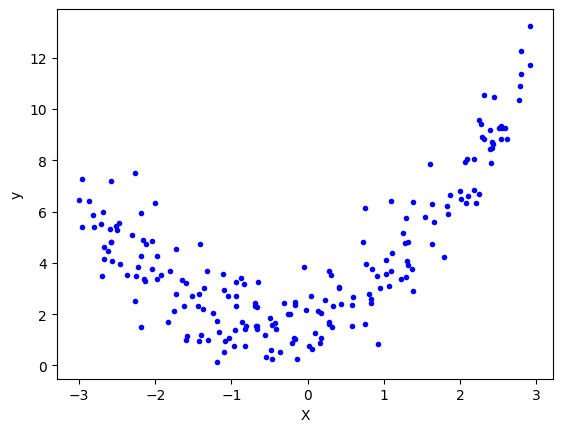

In [6]:
plt.plot(X,y,"b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [7]:
#train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 2)

In [8]:
#applying linear regression
lr = LinearRegression()

In [9]:
lr.fit(X_train,y_train)

LinearRegression()

In [11]:
y_pred =  lr.predict(X_test)
r2_score(y_test,y_pred)

0.20071361531369403

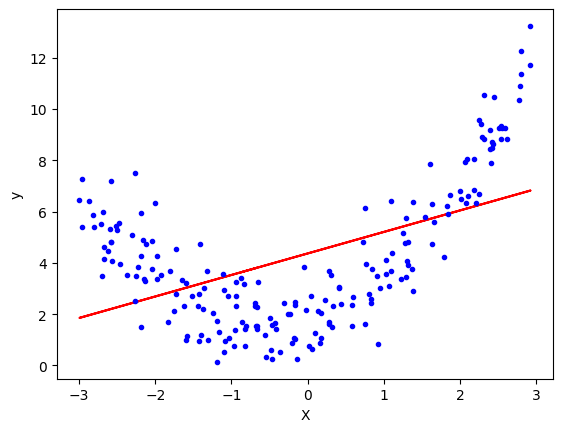

In [12]:
plt.plot(X_train,lr.predict(X_train),color = 'r')
plt.plot(X,y,"b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [17]:
#applying polynomial linear reg
poly = PolynomialFeatures(degree=2,include_bias=True)


X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.fit_transform(X_test)

In [18]:
print(X_train[0])
print(X_train_trans[0])

[-0.86868289]
[ 1.         -0.86868289  0.75460996]


In [19]:
#include bias parameter
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [20]:
y_pred = lr.predict(X_test_trans)
r2_score(y_test,y_pred)


0.7915753817697443

In [21]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.91037924 0.83375215]]
[1.93863009]


In [22]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

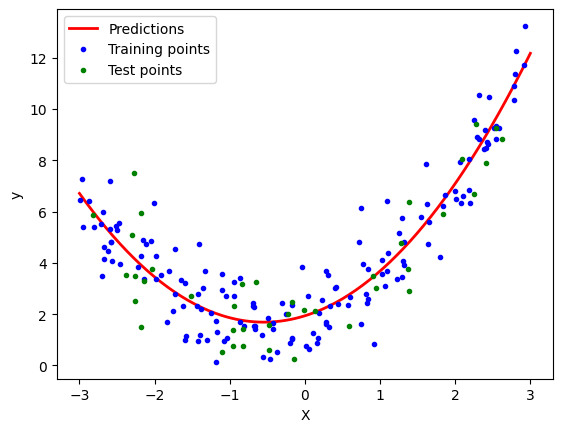

In [24]:
plt.plot(X_new,y_new,"r-",linewidth = 2,label = "Predictions")
plt.plot(X_train,y_train,"b.",label = "Training points")
plt.plot(X_test,y_test,"g.",label = "Test points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()